# Analysis of user demand for events in Yandex Afisha

- Author: Vladislav Wiesner

## Main project objectives:

- Conduct exploratory data analysis (EDA) to identify patterns in user activity and sales.
- Test statistical hypotheses related to user behavior on different types of devices.
- Prepare recommendations for the team based on the data obtained.

## Project objectives:

- Load data into a data frame and review the data
- Check the data for research analysis
- Analyze the distribution of orders and revenue
- Compare mobile and desktop users using a statistical test
- Prepare visualizations and conclusions with recommendations for presenting the results

## The data consists of two datasets:

Description of the `final_tickets_orders_df (orders_df)` dataset - contains information about ticket orders:

- `order_id` — unique order identifier.
- `user_id` — unique user identifier.
- `created_dt_msk` — order creation date (Moscow time).
- `created_ts_msk` — date and time of order creation (Moscow time).
- `event_id` — event identifier from the events table.
- `cinema_circuit` — cinema chain. If not applicable, the value ‘no’ will be displayed here.
- `age_limit` — age restriction for the event.
- `currency_code` — payment currency, e.g. rub for Russian rubles.
- `device_type_canonical` — type of device used to place the order, e.g. mobile for mobile devices, desktop for stationary devices.
- `revenue` — revenue from the order.
- `service_name` — name of the ticket operator.
- `tickets_count` — number of tickets purchased.
- `total` — total amount of the order.
- `days_since_prev` - number of days since the previous purchase for each user.

Description of the dataset `final_tickets_events_df (events_df)` - contains information about events:

- `event_id` — unique event identifier.
- `event_name` — name of the event. Equivalent to the event_name_code field in the source database.
- `event_type_description` — description of the event type.
- `event_type_main` — main type of event: theater performance, concert, etc.
- `organizers` — event organizers.
- `region_name` — name of the region.
- `city_name` — name of the city.
- `venue_id` — unique identifier of the venue.
- `venue_name` — name of the venue.
- `venue_address` — address of the venue.

There is also an additional dataset with information on the tenge exchange rate against the Russian ruble for 2024 - `final_tickets_tenge_df.csv`:

- `nominal` — nominal value (100 tenge).
- `data` — date.
- `curs` — tenge to ruble exchange rate.
- `cdx` — currency code (kzt).
---

### 1. Downloading data and familiarizing yourself with it



In [52]:
# Import the library for analysis
import pandas as pd
import numpy as np

# Import libraries for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

In [54]:
url = 'https://code.s3.yandex.net/datasets/'
# Load data into dataframes orders_df and events_df
orders_df = pd.read_csv(f'{url}final_tickets_orders_df.csv')

events_df = pd.read_csv(f'{url}final_tickets_events_df.csv')
tickets_tenge_df = pd.read_csv(f'{url}final_tickets_tenge_df.csv')

# Display information and the first rows of the dataframe
orders_df.info()
orders_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


The dataframe `orders_df` has 14 columns containing 290,848 rows. After a first glance at the data, the following conclusions can be drawn:
- Column names are user-friendly
- The dataframe contains mostly `object` data types in 7 columns, 4 columns with `int64` data types, and 3 columns with `float64` data types.
- The columns `created_dt_msk` and `created_ts_msk` will need to be converted to the datetime data type for convenient data analysis
- One column contains gaps - `days_since_prev`.
- The values in the columns correspond to their names.

In [56]:
# Display information and the first rows of the data frame
events_df.info()
events_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


The dataframe `events_df` has 11 columns containing 22,426 rows. After a first glance at the data, the following conclusions can be drawn:
- The column names are user-friendly.
- The dataframe contains mostly `object` data types in 8 columns and `int64` data types in 3 columns.
- There are no gaps in the dataframe columns.
- The values in the columns correspond to their names.
---

###  2. Preprocessing data and preparing it for research

In [59]:
# Let's check the data frames for the number of missing values
orders_df.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

Gaps are only present in the `days_since_prev` column, amounting to 21,940 rows.

In [61]:
events_df.isna().sum()

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

There are no more gaps in the event data frame, which is good.

In [63]:
# check for unique values in selected columns
unique_values = ['currency_code', 'device_type_canonical', 'service_name', 'cinema_circuit']
for col in unique_values:
    print(f"Unique values in {col}: {orders_df[col].unique()}")

Unique values in currency_code: ['rub' 'kzt']
Unique values in device_type_canonical: ['mobile' 'desktop']
Unique values in service_name: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
Unique values in cinema_circuit: ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']


There are no spelling errors in the selected values.

Statistics for revenue (rub):
count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64


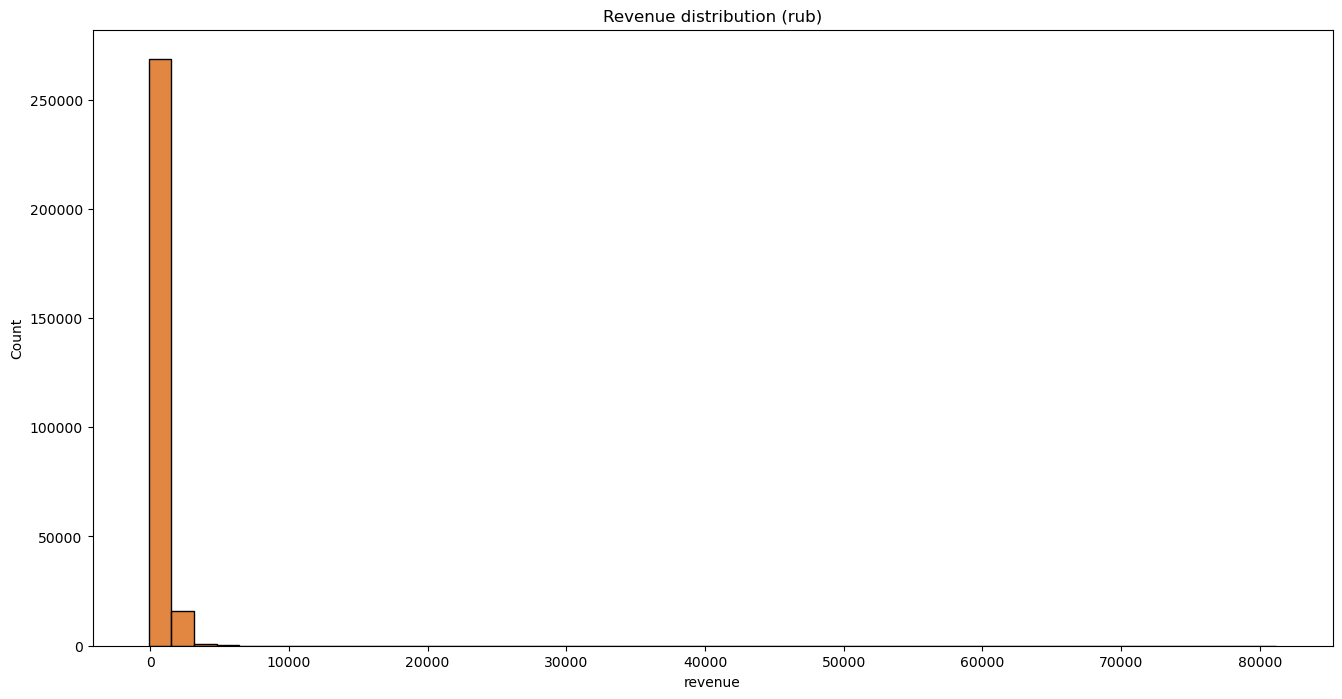

Statistics for revenue (kzt):
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64


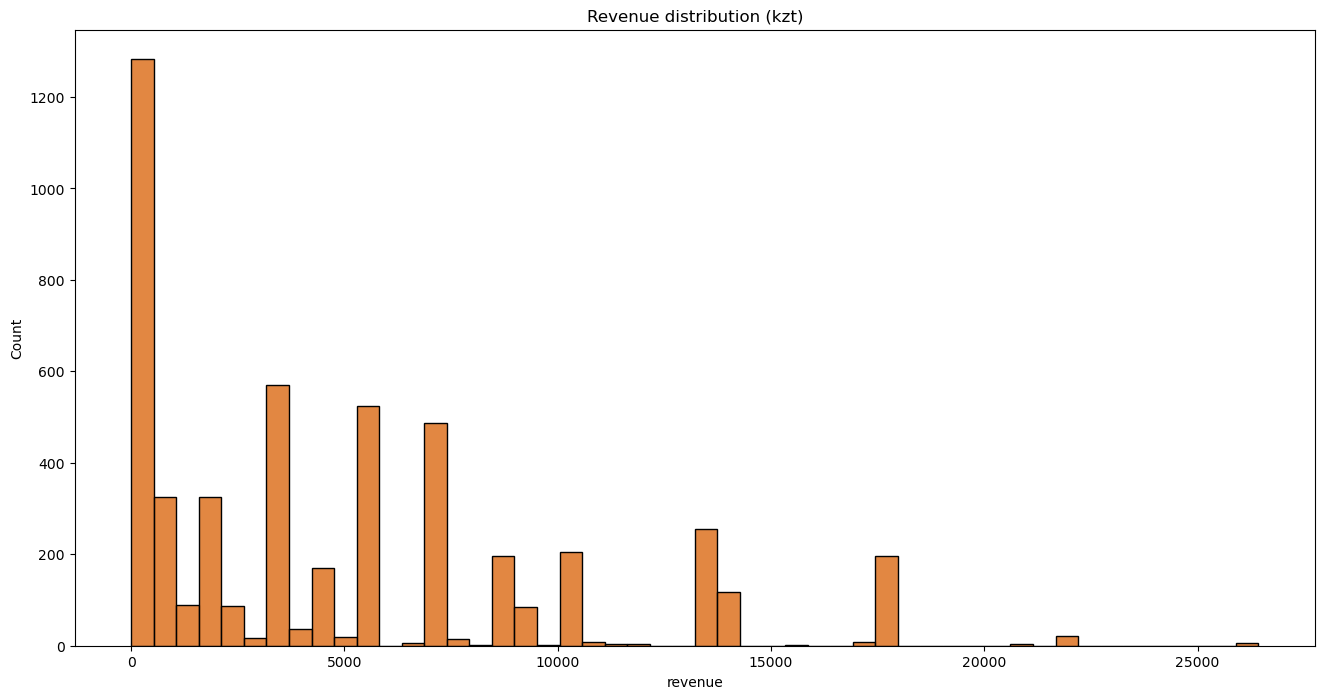

In [65]:
# revenue analysis by currency
for currency in ['rub', 'kzt']:
    subset = orders_df[orders_df['currency_code'] == currency]
    print(f"Statistics for revenue ({currency}):")
    print(subset['revenue'].describe())

    plt.figure(figsize=(16, 8))
    # building a histogram
    sns.histplot(subset['revenue'], bins=50, color='#d95f02')
    plt.title(f"Revenue distribution ({currency})")
    plt.show()

The `revenue` data in rubles contains large outliers and negative values, possibly due to returned orders or input errors. Let's remove the negative values and outliers and look at the histogram again.

There are also large outliers in tenge, so let's remove them as well. 

Statistics for revenue (rub):
count    282599.000000
mean        511.081158
std         500.914005
min           0.000000
25%         112.440000
50%         341.010000
75%         782.080000
max        2570.800000
Name: revenue, dtype: float64


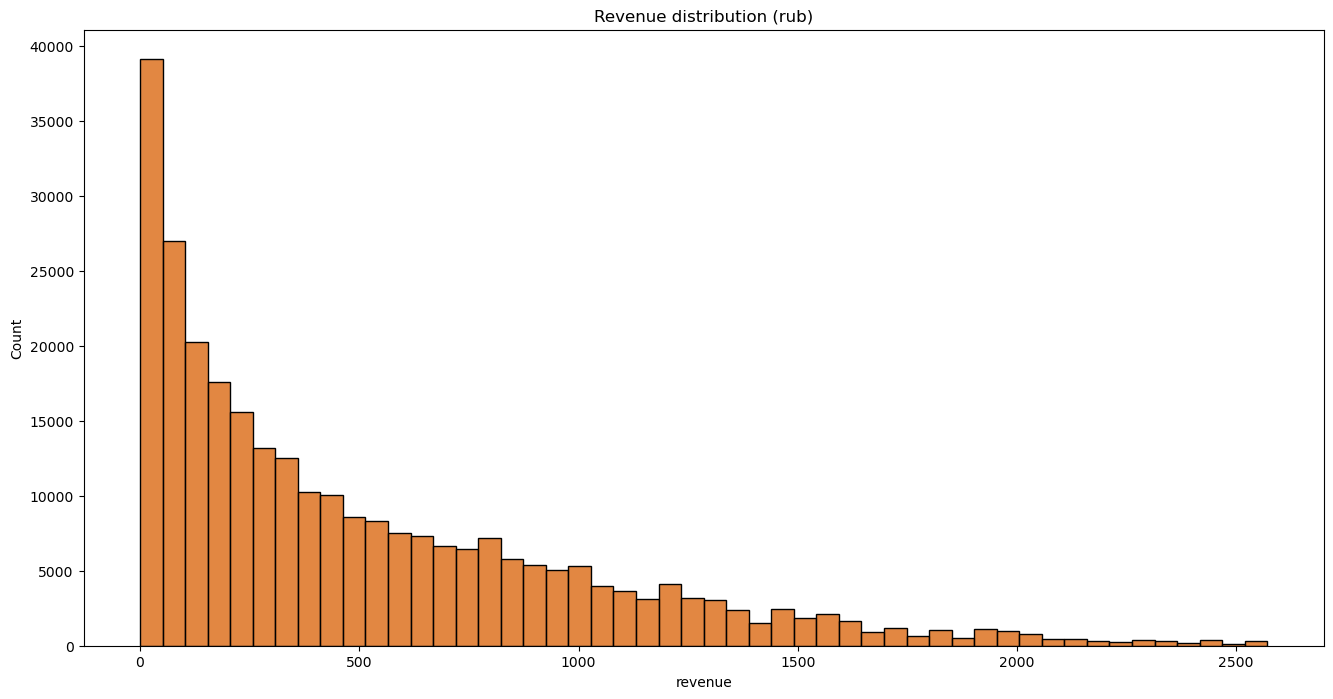

Statistics for revenue (kzt):
count     5040.000000
mean      4893.669063
std       4742.680176
min          0.000000
25%        515.350000
50%       3698.830000
75%       7397.660000
max      17617.240000
Name: revenue, dtype: float64


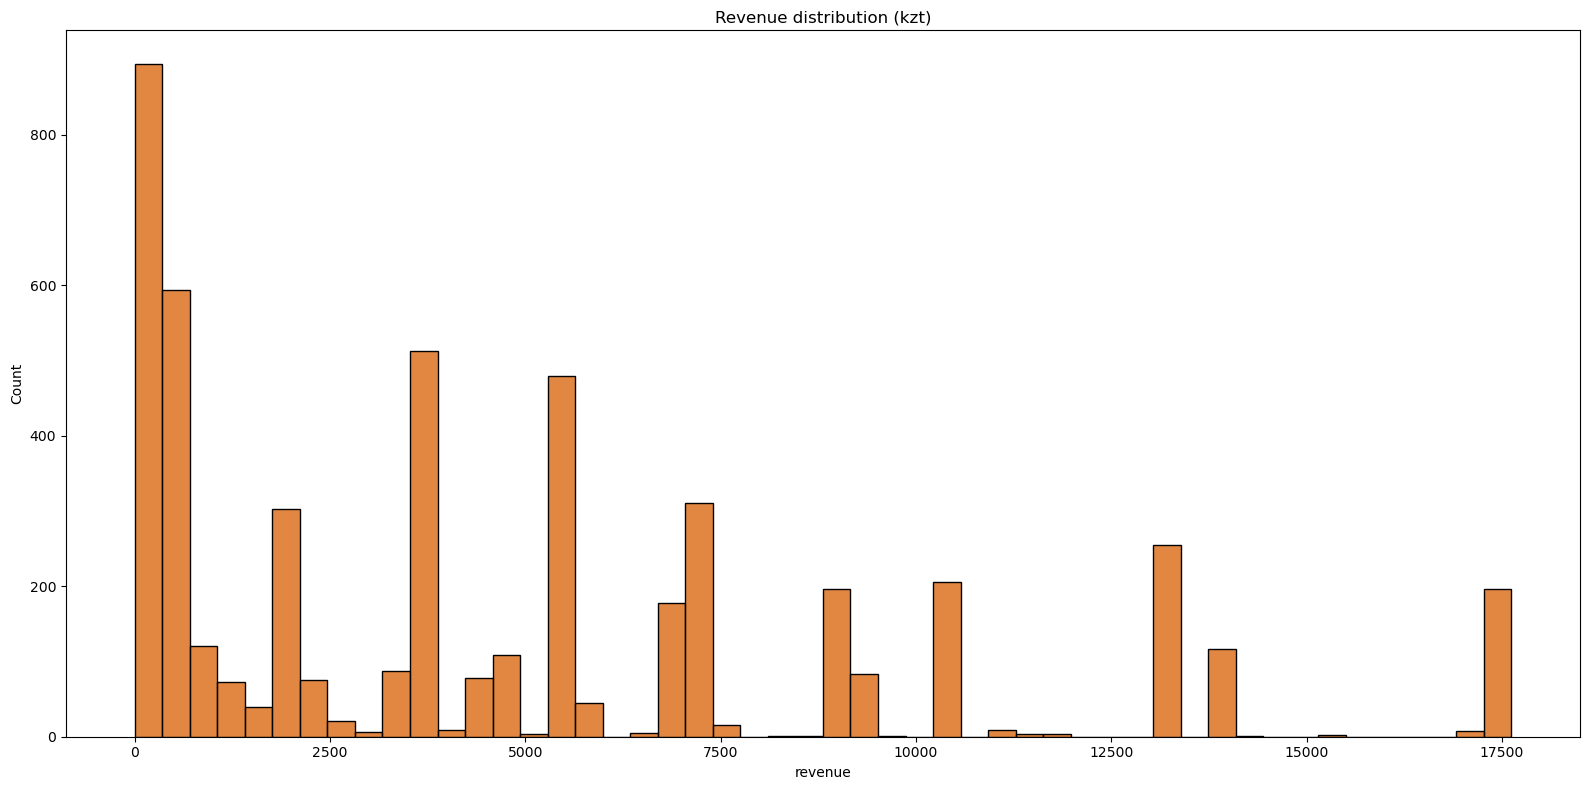

In [67]:
# exclude negative values
df_rub = orders_df[orders_df['currency_code'] == 'rub'].copy()
df_rub = df_rub[df_rub['revenue'] >= 0] 

emission_free = df_rub['revenue'].quantile(0.99)
df_rub = df_rub[df_rub['revenue'] <= emission_free]

print(f"Statistics for revenue (rub):")
print(df_rub['revenue'].describe())

plt.figure(figsize=(16, 8))
# building a histogram
sns.histplot(df_rub['revenue'], bins=50, color='#d95f02')
plt.title(f"Revenue distribution (rub)")
plt.show()


# exclude value emissions  
df_kzt = orders_df[orders_df['currency_code'] == 'kzt'].copy()

emission_free_kzt = df_kzt['revenue'].quantile(0.99)
df_kzt = df_kzt[df_kzt['revenue'] <= emission_free_kzt]

print(f"Statistics for revenue (kzt):")
print(df_kzt['revenue'].describe())

plt.figure(figsize=(16, 8))
# building a histogram
sns.histplot(df_kzt['revenue'], bins=50, color='#d95f02')
plt.title(f"Revenue distribution (kzt)")
plt.tight_layout()
plt.show()

In [68]:
# combining filtered data into a single table
orders_df = pd.concat([df_rub, df_kzt]).reset_index(drop=True)

# Verification of results after connection
print("Statistics for revenue in orders_df:")
display(orders_df.groupby('currency_code')['revenue'].describe())

Statistics for revenue in orders_df:


,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5040.0,4893.669063,4742.680176,0.0,515.35,3698.83,7397.66,17617.24
rub,282599.0,511.081158,500.914005,0.0,112.44,341.01,782.08,2570.80


Statistics for tickets_count:
count    287639.000000
mean          2.740974
std           1.162340
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64


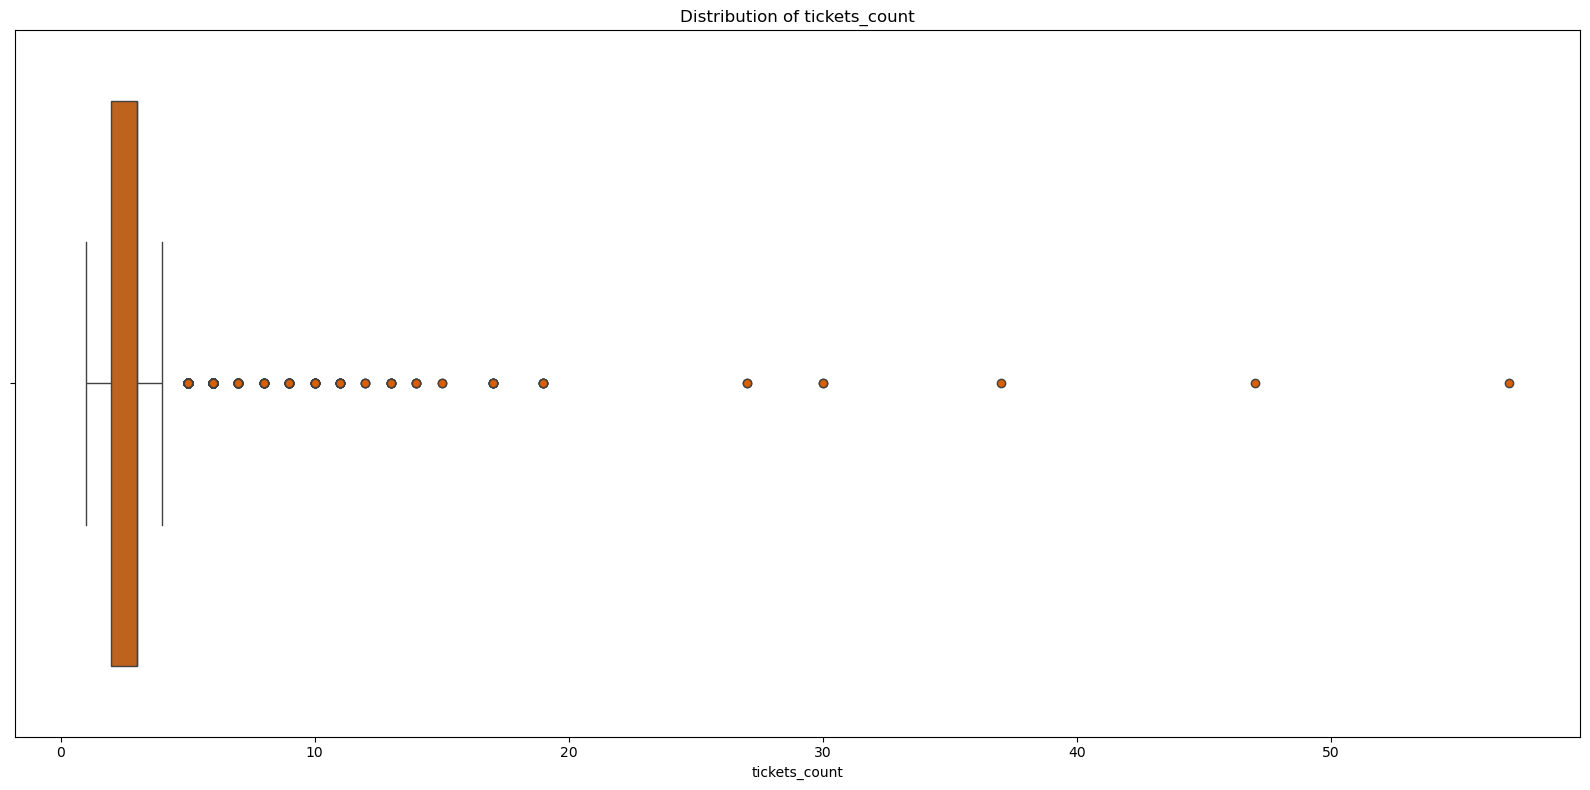

In [69]:
# Let's examine the statistics of values in tickets_count.
print(f"Statistics for tickets_count:")
print(orders_df['tickets_count'].describe())

plt.figure(figsize=(16, 8))
# building a histogram
sns.boxplot(data=orders_df, x='tickets_count', color='#d95f02',
           flierprops=dict(markerfacecolor='#d95f02', marker='o'))

plt.title(f"Distribution of tickets_count")
plt.tight_layout()
plt.show()

In the `tickets_count` column with the number of tickets purchased, there are some outliers, the largest of which is 57 tickets. When the 75th percentile shows 4 tickets.

In [71]:
# Checking for complete duplicates in the data frame
orders_df.duplicated().sum()

0

In [72]:
# Checking for complete duplicates in the data frame 
events_df.duplicated().sum()

0

Great. There are no complete duplicate rows in the two data frames.

Let's check for implicit duplicates in `orders_df` — values by customer user_id:

In [74]:
# Checking for implicit duplicates in the data frame for selected columns
columns_dup = ['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 'age_limit', 'currency_code',
               'device_type_canonical', 'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev']

duplicates = orders_df[orders_df.duplicated(columns_dup, keep=False)]
print(f"Found {len(duplicates)} potential duplicates.")

Found 58 potential duplicates.


58 duplicates were found in the selected columns for duplicate search, possibly due to a system error. Let's delete these duplicates so they don't get in the way.

In [76]:
# remove duplicates
orders_df = orders_df.drop_duplicates(columns_dup, keep='first')

# let's check again
columns_dup = ['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 'age_limit', 'currency_code',
               'device_type_canonical', 'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev']

duplicates = orders_df[orders_df.duplicated(columns_dup, keep=False)]
print(f"Found {len(duplicates)} potential duplicates.")

Found 0 potential duplicates.


In [77]:
# convert values to datetime
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
orders_df['created_ts_msk'] = pd.to_datetime(orders_df['created_ts_msk'])

tickets_tenge_df['data'] = pd.to_datetime(tickets_tenge_df['data'])

# Let's check the changes.
orders_df[['created_dt_msk', 'created_ts_msk']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 287609 entries, 0 to 287638
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   created_dt_msk  287609 non-null  datetime64[ns]
 1   created_ts_msk  287609 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 6.6 MB


In [78]:
# Optimize the integer data type in the orders_df dataframe
orders_df['age_limit'] = pd.to_numeric(orders_df['age_limit'], downcast='integer') 
orders_df['age_limit'].dtypes

dtype('int8')

In [79]:
# Combine data frames for calculations
orders_df_with_transfer = pd.merge(orders_df, tickets_tenge_df, how='left',
                                   left_on='created_dt_msk',
                                   right_on='data')

# Convert tenge to rubles
orders_df['revenue_rub'] = orders_df_with_transfer.apply(lambda row: row['revenue'] if row['currency_code'] == 'rub' 
                                    else (row['revenue'] / 100) * row['curs'],
                                    axis=1)
# Rounded to the nearest penny
orders_df['revenue_rub'] = orders_df['revenue_rub'].round(2)

# Calculate the revenue from each ticket
orders_df['one_ticket_revenue_rub'] = (orders_df['revenue_rub'] / orders_df['tickets_count']).round(2)

# Let's create a column with months.
orders_df['month'] = orders_df['created_dt_msk'].dt.month

# sort the month number by 
def seasons(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'autumn'
    else:
        return 'unknown'

orders_df['season'] = orders_df['month'].apply(seasons)

# Let's check our new columns.
orders_df[orders_df['currency_code'] == 'kzt'].head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,revenue_rub,one_ticket_revenue_rub,month,season
282599,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,Билеты без проблем,4,10361.97,20.0,3504.56,876.14,9,autumn
282600,8634925,0040e12d70fae81,2024-09-02,2024-09-02 19:49:14,559476,нет,6,kzt,desktop,347.18,Билеты без проблем,3,6943.61,39.0,2628.42,876.14,9,autumn
282601,7625522,0054b38b2653e6e,2024-09-09,2024-09-09 18:06:04,559582,нет,6,kzt,mobile,328.77,Билеты без проблем,4,10959.07,NaN,735.80,183.95,9,autumn
282602,5227657,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:28:17,533803,нет,16,kzt,desktop,7397.66,Мой билет,4,123294.32,1.0,367.90,91.98,6,summer
282603,2229782,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:17:35,533803,нет,16,kzt,mobile,3698.83,Мой билет,2,61647.16,0.0,735.80,367.90,6,summer


### Interim conclusion:

The data provided is of good quality and does not require much preprocessing.

As a result, the following was done:

- Corrected the data type in the `age_limit` column, namely optimized it to int8
- Examined missing values throughout the data frame, checked for explicit and implicit duplicates, which were then removed
- We checked the values for outliers in the `revenue` and `tickets_count` columns.
- We created new columns `revenue_rub`, `one_ticket_revenue_rub`, `month`, and `season` for further analysis.

---

### 3. Research data analysis

In [82]:
orders_with_events = pd.merge(orders_df, events_df, how='left', on='event_id')

# group data by month and event
event_count_per_month = orders_with_events.groupby(['month', 'event_type_main']).agg(
    orders_count=('order_id', 'count')).reset_index().sort_values(by='orders_count', ascending=False)

event_count_per_month['orders_share'] = (100.0 * (event_count_per_month['orders_count'] / event_count_per_month['orders_count'].sum())).round(2)
display(event_count_per_month)

,month,event_type_main,orders_count,orders_share
30,10,концерты,37790,13.15
33,10,театр,25098,8.73
23,9,концерты,24949,8.68
29,10,другое,18578,6.46
16,8,концерты,18518,6.44
26,9,театр,17637,6.14
9,7,концерты,16761,5.83
2,6,концерты,15489,5.39
22,9,другое,14493,5.04
15,8,другое,12021,4.18


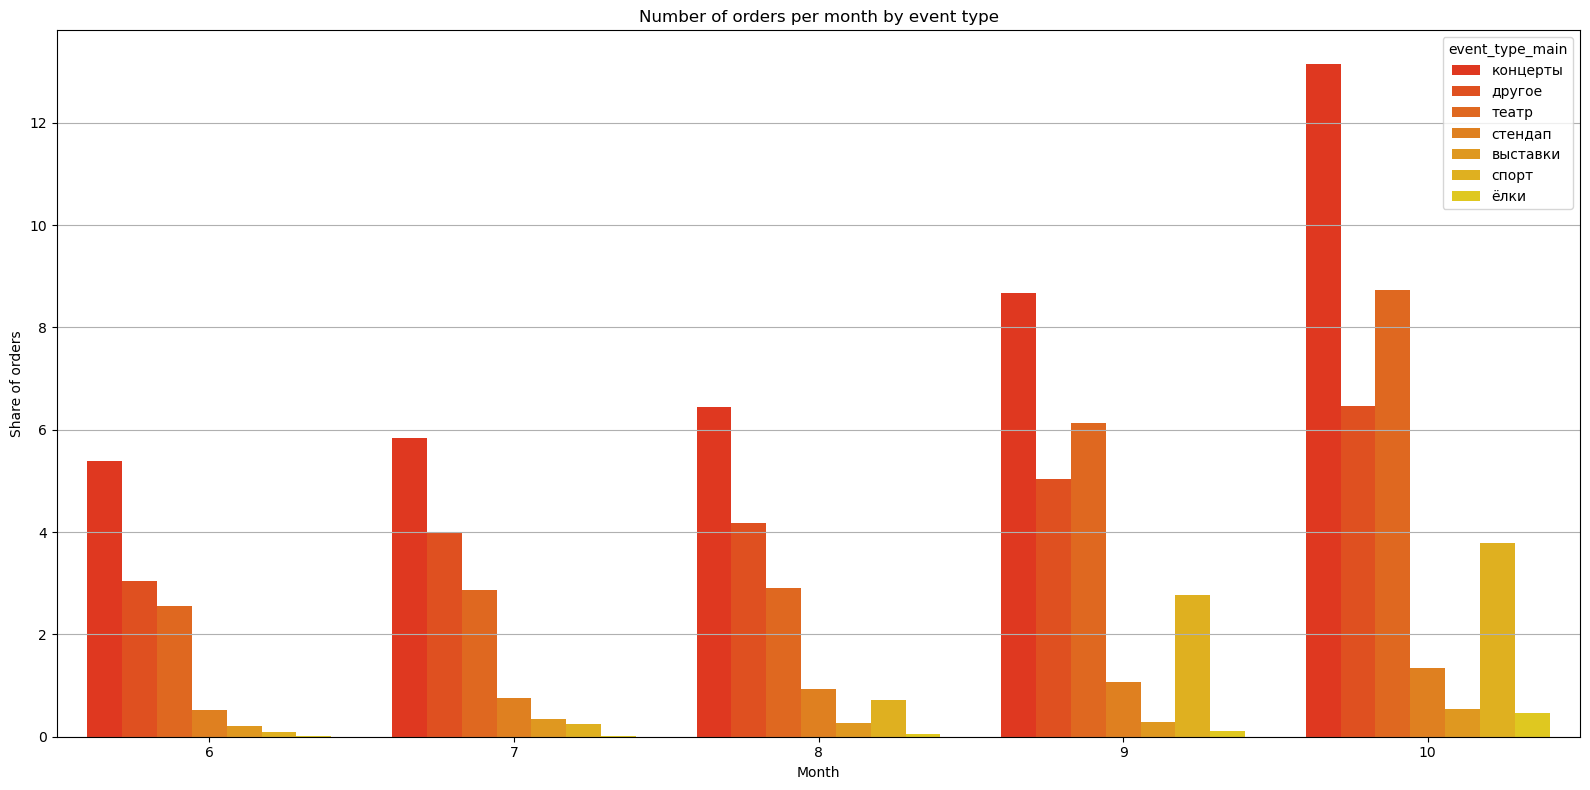

In [100]:
plt.figure(figsize=(16, 8))

# let's make a schedule
sns.barplot(data=event_count_per_month,
            x='month',
            y='orders_share',
            hue='event_type_main',
            palette='autumn')

plt.ylabel('Share of orders')
plt.xlabel('Month')
plt.title('Number of orders per month by event type')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The graph shows that the number of orders increases every month. For example, in June (6), the total number of orders was 34,676 (11.90%), and with each passing month, our indicators for each type of event increased. By November (10), the total number of orders had reached 99,170 (34.48%). orders had already reached 99,170, or 34.48%. 

Now let's look at the data in the device type section to see which device was used to place the most orders by month:

In [103]:
count_device_per_month = orders_df.groupby(['month', 'device_type_canonical']).agg(
    orders_count=('order_id', 'count')).reset_index().sort_values(by='orders_count', ascending=False)


count_device_per_month['orders_share'] = (100.0 * (count_device_per_month['orders_count'] / count_device_per_month['orders_count'].sum())).round(2)
display(count_device_per_month)

,month,device_type_canonical,orders_count,orders_share
9,10,mobile,78262,27.21
7,9,mobile,55887,19.43
5,8,mobile,36257,12.61
3,7,mobile,32470,11.29
1,6,mobile,27344,9.51
8,10,desktop,20908,7.27
6,9,desktop,13388,4.65
4,8,desktop,8305,2.89
2,7,desktop,7897,2.75
0,6,desktop,6891,2.40


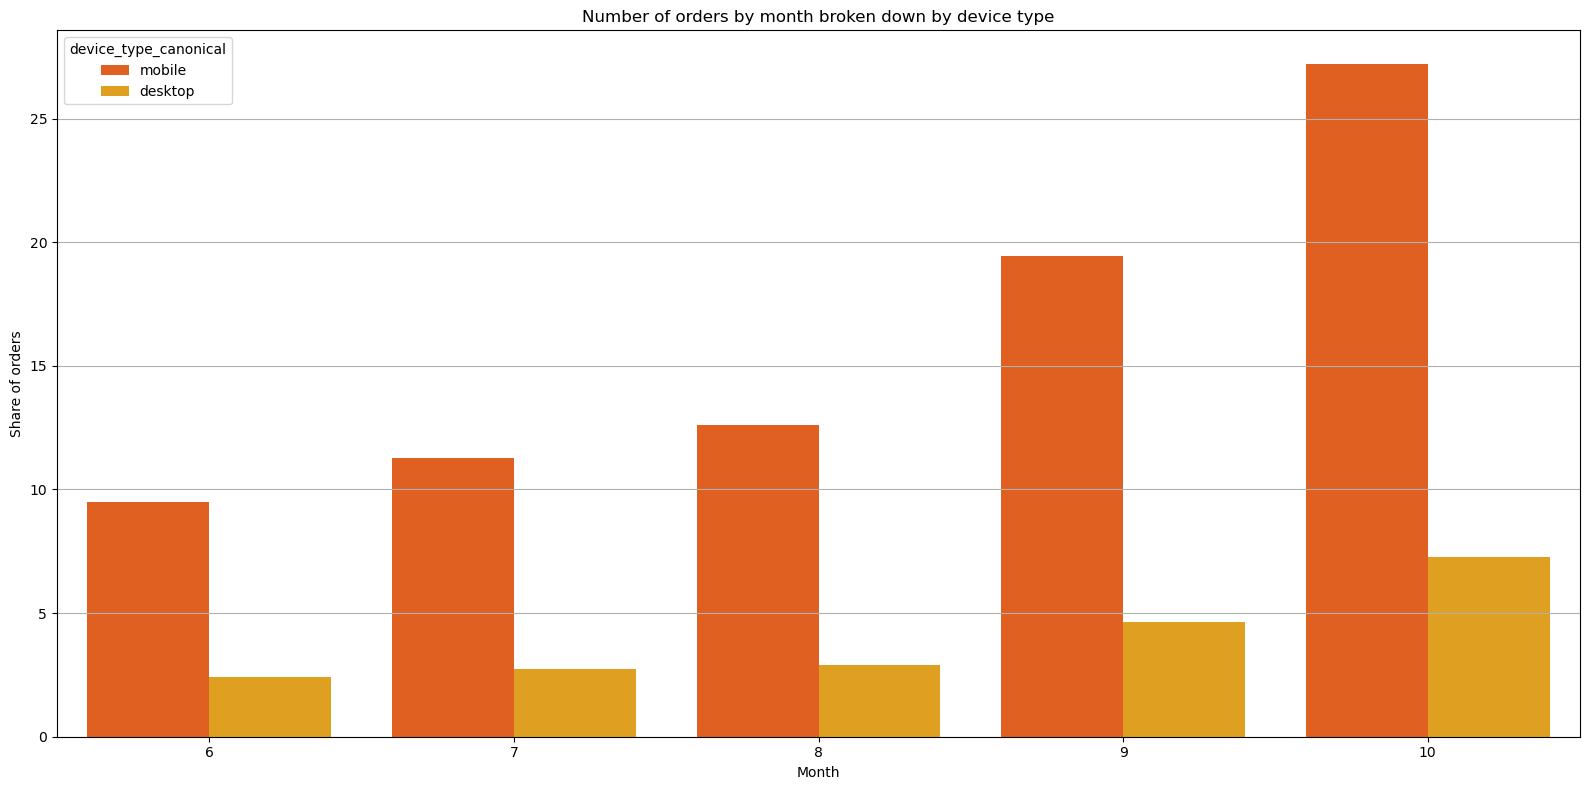

In [105]:
plt.figure(figsize=(16, 8))

# let's make a schedule
sns.barplot(data=count_device_per_month,
            x='month',
            y='orders_share',
            hue='device_type_canonical',
            palette='autumn')

plt.ylabel('Share of orders')
plt.xlabel('Month')
plt.title('Number of orders by month broken down by device type')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

As with the graph for the type of event, we see an increase in the graph values with each month. So, in June (6), 27,344 (9.51%) users made a purchase from their phone (mobile), and 6,891 (2.40%) users made a purchase from their computer (desktop). In November (10), the number of users who placed an order from their phone (mobile) already amounted to 78,259-27.21%, and 20,908-7.27% of users made a purchase from a computer (desktop).

In [108]:
counts_age_per_month = orders_df.groupby(['month', 'age_limit']).agg(
    orders_count=('order_id', 'count')).reset_index().sort_values(by='orders_count', ascending=False)

counts_age_per_month['orders_share'] = (100.0 * (counts_age_per_month['orders_count'] / counts_age_per_month['orders_count'].sum())).round(2)
display(counts_age_per_month)

,month,age_limit,orders_count,orders_share
23,10,16,26553,9.23
20,10,0,23838,8.29
22,10,12,21429,7.45
18,9,16,17659,6.14
21,10,6,16924,5.88
15,9,0,15870,5.52
17,9,12,15846,5.51
16,9,6,12759,4.44
13,8,16,12117,4.21
8,7,16,11780,4.10


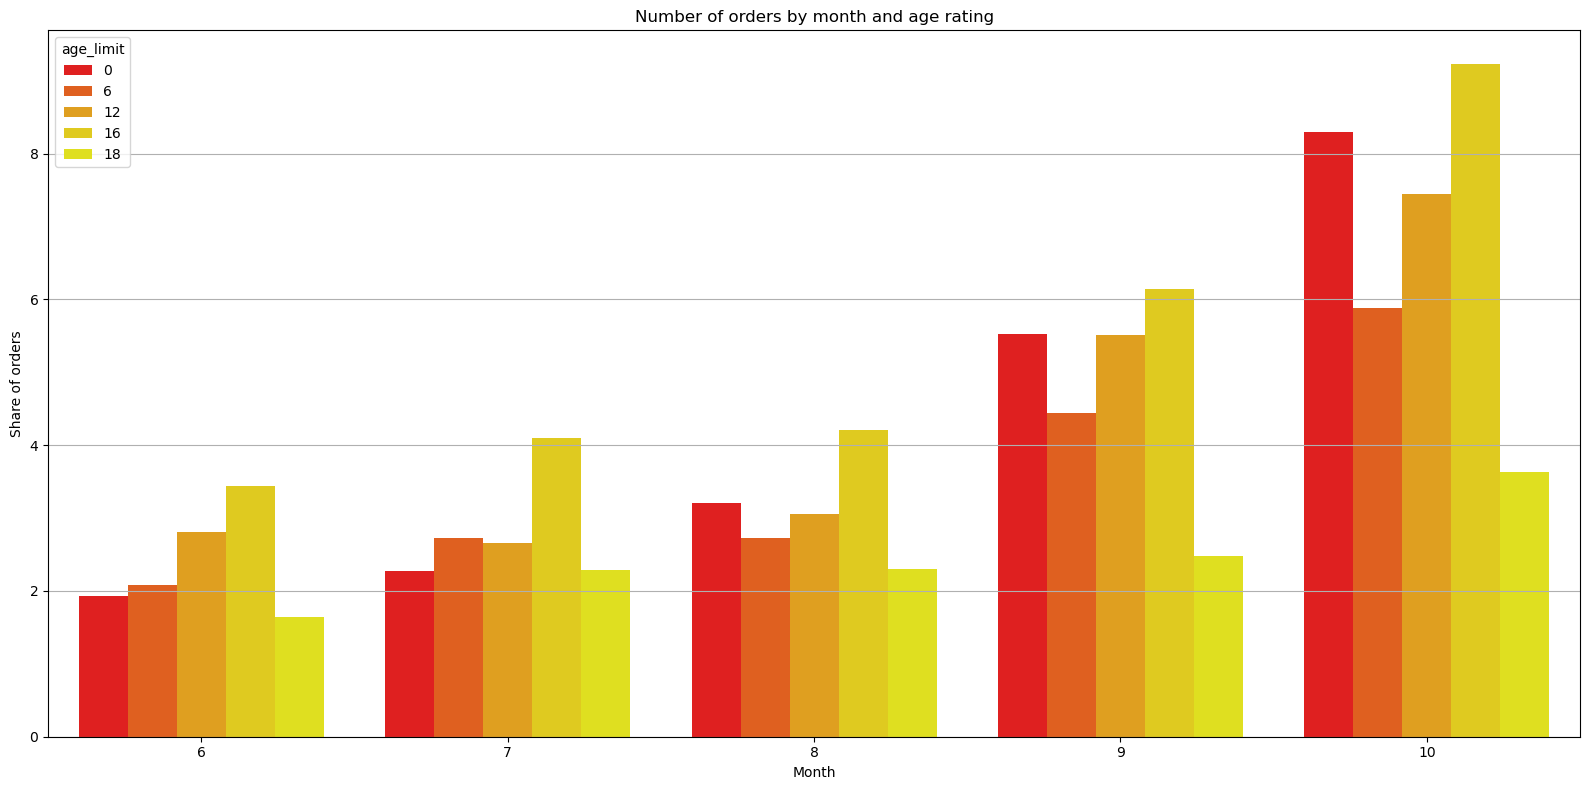

In [112]:
plt.figure(figsize=(16, 8))

# let's make a schedule
sns.barplot(data=counts_age_per_month,
            x='month',
            y='orders_share',
            hue='age_limit',
            palette='autumn')

plt.ylabel('Share of orders')
plt.xlabel('Month')
plt.title('Number of orders by month and age rating')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Most events start at age 16. Next are events in June (6) 8083-2.81% for ages 12 and up, followed by July (7) in second place in terms of number of events.  There are events for ages 6 and up (7831-2.72%), and then there are more events with an age restriction of 16 and up. Starting in August (8), events without age restrictions become more popular. This may be related to summer vacation, when there are more children's events. 

In [115]:
# group data by month and event
event_count_per_season = orders_with_events.groupby(['season', 'event_type_main']).agg(
    ticket_count=('tickets_count', 'count')).reset_index().sort_values(by='ticket_count', ascending=False)

event_count_per_season['orders_share'] = (100.0 * (event_count_per_season['ticket_count'] / event_count_per_season['ticket_count'].sum())).round(2)
display(event_count_per_season)

,season,event_type_main,ticket_count,orders_share
2,autumn,концерты,62739,21.83
9,summer,концерты,50768,17.67
5,autumn,театр,42735,14.87
1,autumn,другое,33071,11.51
8,summer,другое,32208,11.21
12,summer,театр,23943,8.33
3,autumn,спорт,18862,6.56
4,autumn,стендап,6923,2.41
11,summer,стендап,6346,2.21
10,summer,спорт,3003,1.04


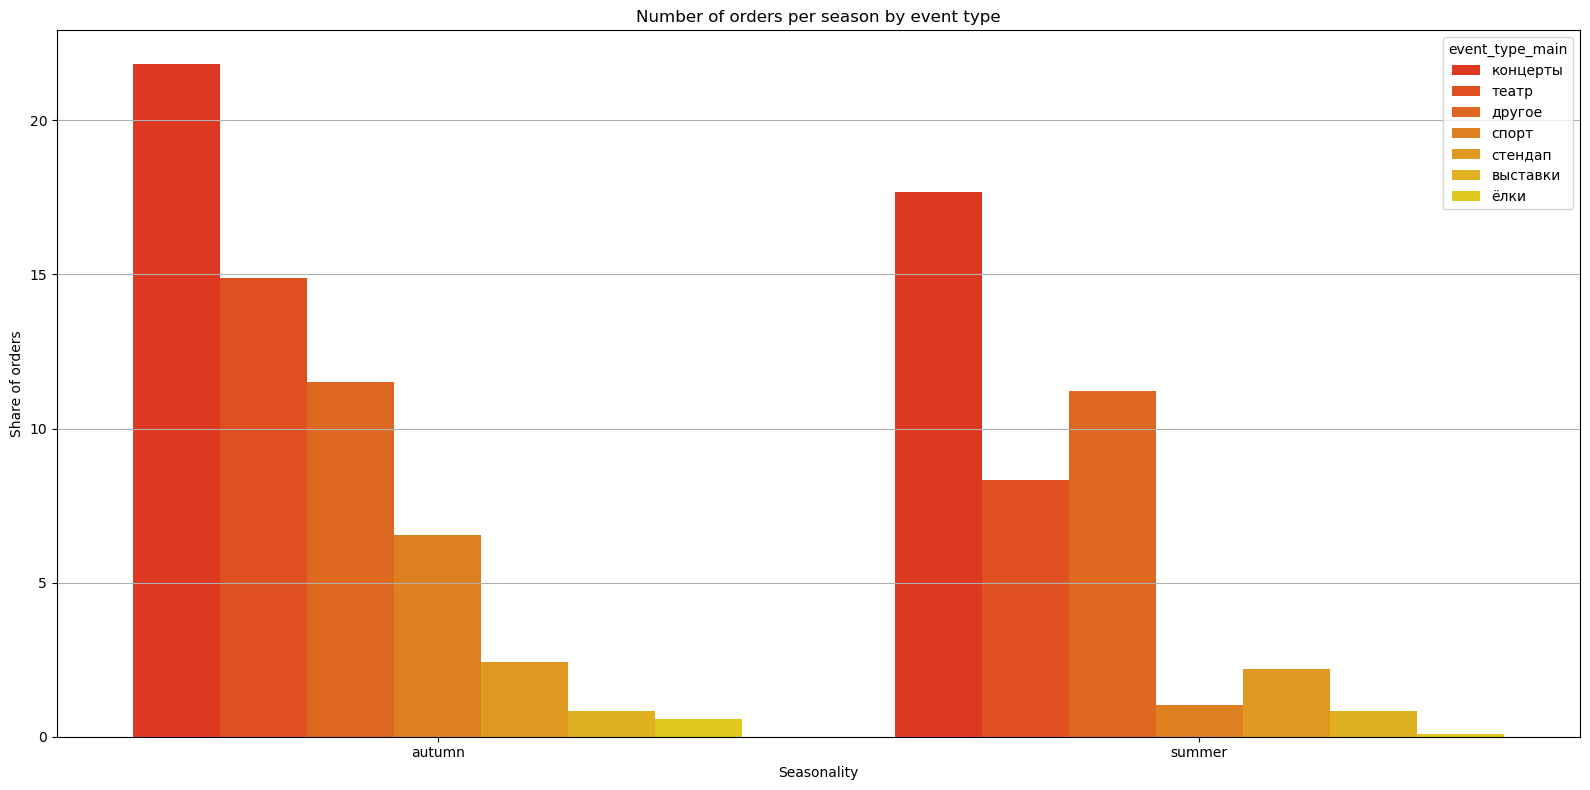

In [117]:
plt.figure(figsize=(16, 8))

# let's make a schedule
sns.barplot(data=event_count_per_season,
            x='season',
            y='orders_share',
            hue='event_type_main',
            palette='autumn')

plt.ylabel('Share of orders')
plt.xlabel('Seasonality')
plt.title('Number of orders per season by event type')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The largest number of orders is also for concerts. Only in summer do other types of events come second, with theaters coming in second place in terms of number of orders.

,season,device_type_canonical,ticket_count,total_counts,ticket_share
1,summer,mobile,96071,119164,0.806208
0,autumn,mobile,134149,168445,0.796396
2,autumn,desktop,34296,168445,0.203604
3,summer,desktop,23093,119164,0.193792


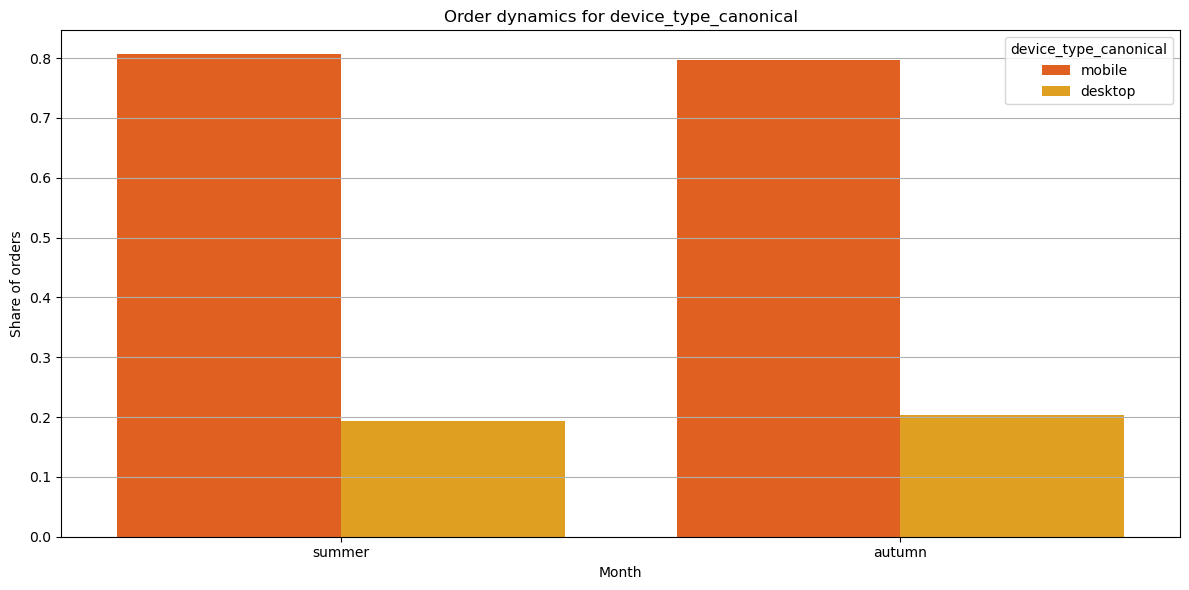

,season,age_limit,ticket_count,total_counts,ticket_share
3,summer,16,33778,119164,0.283458
0,autumn,16,44212,168445,0.262471
1,autumn,0,39708,168445,0.235733
2,autumn,12,37275,168445,0.221289
5,summer,12,24497,119164,0.205574
6,summer,6,21671,119164,0.181859
7,summer,0,21274,119164,0.178527
4,autumn,6,29683,168445,0.176218
8,summer,18,17944,119164,0.150582
9,autumn,18,17567,168445,0.104289


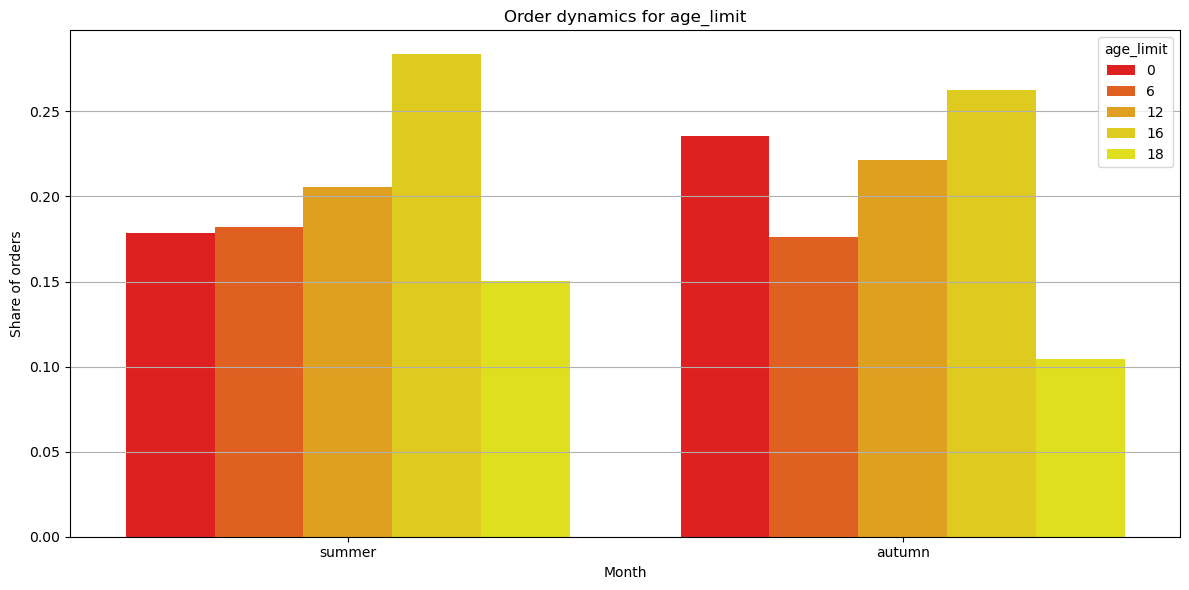

In [120]:
for segment in ['device_type_canonical', 'age_limit']:
    segment_stats = orders_df.groupby(['season', segment]).agg(
    ticket_count=('tickets_count', 'count')).reset_index().sort_values(by='ticket_count', ascending=False)
    
    # let's calculate the total for each season
    season_totals = segment_stats.groupby('season')['ticket_count'].sum().reset_index()
    season_totals.rename(columns={'ticket_count': 'total_counts'}, inplace=True)
    
    segment_stats = segment_stats.merge(season_totals, on='season')
    
    # find shares
    segment_stats['ticket_share'] = (segment_stats['ticket_count'] / segment_stats['total_counts'])
    
    segment_stats = segment_stats.sort_values(by='ticket_share', ascending=False)
    
    display(segment_stats)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=segment_stats,
        x='season',
        y='ticket_share',
        hue=segment,
        palette='autumn')
    
    plt.title(f'Order dynamics for {segment}')
    plt.xlabel('Month')
    plt.ylabel('Share of orders')
    plt.xticks(rotation=0)
    plt.legend(title=segment)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

Looking at all the graphs, we can say that autumn is more profitable for Yandex Afisha, because at this time there was more revenue from tickets for various types of events. 

The graph showing device type shows that users who placed orders using a mobile phone are in the lead, with a difference of 2 times between users who placed orders on a desktop computer.

In [131]:
# grouped by season and type of event
tickets_revenue_analysis = orders_with_events.groupby(['season', 'event_type_main']).agg(
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')).reset_index()

pivot_table = tickets_revenue_analysis.pivot(index='event_type_main',
                                             columns='season',
                                             values='avg_ticket_price')

pivot_table['change'] = (pivot_table['autumn'] / pivot_table['summer'] - 1) * 100

avg_tickets_with_change = pivot_table.sort_values('change').reset_index()

display(avg_tickets_with_change)

season,event_type_main,autumn,summer,change
0,спорт,136.642367,179.141042,-23.723584
1,ёлки,196.917244,243.543736,-19.145018
2,концерты,252.056071,273.481013,-7.834160
3,стендап,209.617947,217.675405,-3.701593
4,театр,229.909858,236.155545,-2.644734
5,выставки,242.676878,241.483029,0.494382
6,другое,217.707476,214.822551,1.342934


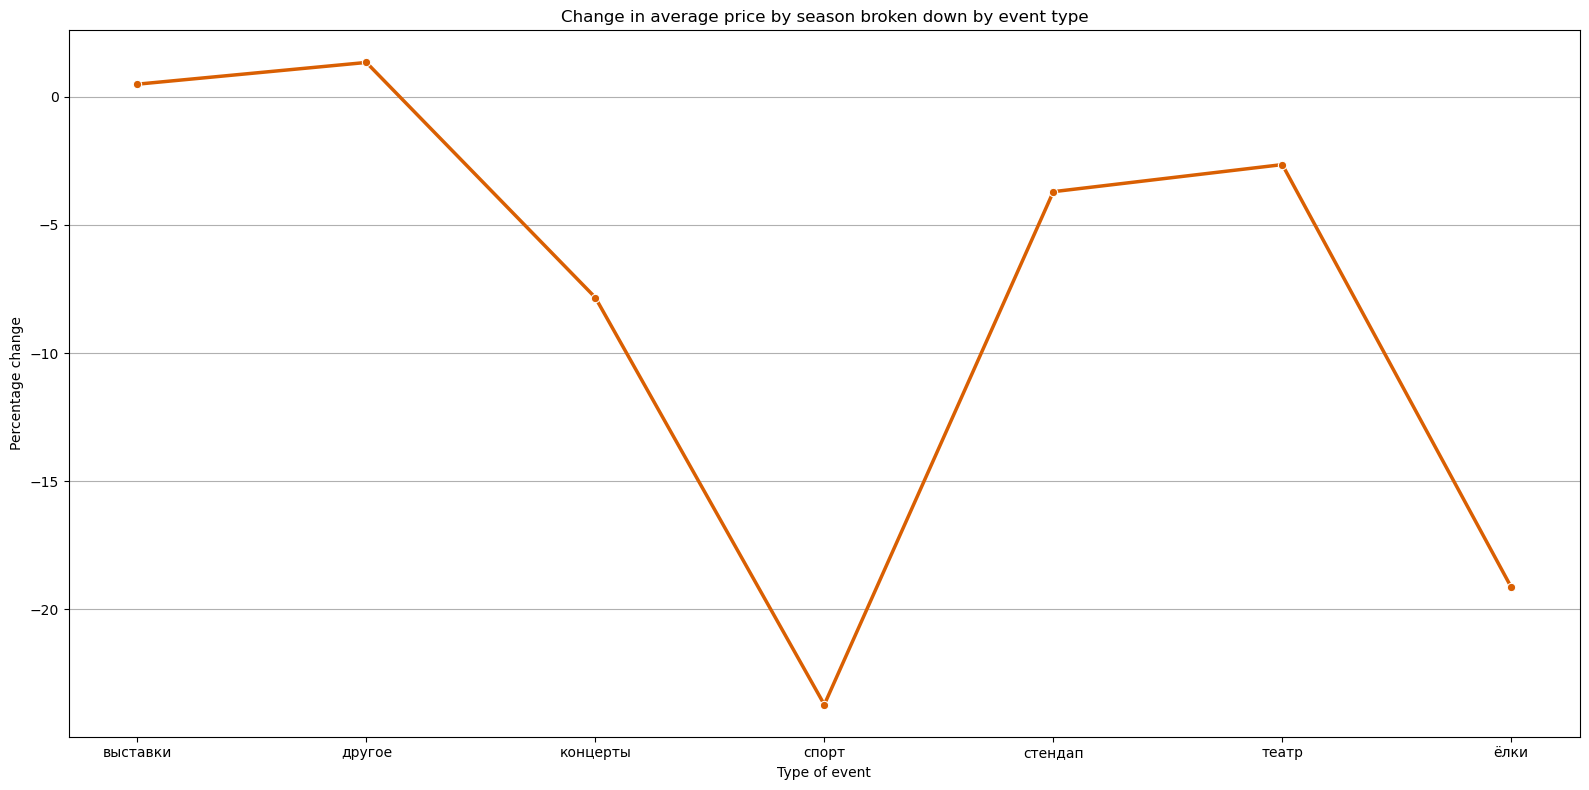

In [135]:
plt.figure(figsize=(16, 8))

# let's make a schedule
sns.lineplot(data=pivot_table,
            x='event_type_main',
            y='change',
            color='#d95f02',
            marker='o',
            linewidth=2.5)

plt.ylabel('Percentage change')
plt.xlabel('Type of event')
plt.title('Change in average price by season broken down by event type')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The graph showing the average revenue per ticket for events differs from the total revenue. Here, higher figures are already seen in the summer for all types of events, without any significant drops. For example, in the fall, the average price in the sports category is less than 140 rubles, while in the summer it was 180 rubles, a difference of approximately 40 rubles. 

,month,orders_count,orders_share
4,10,99170,34.48
3,9,69275,24.09
2,8,44562,15.49
1,7,40367,14.04
0,6,34235,11.90


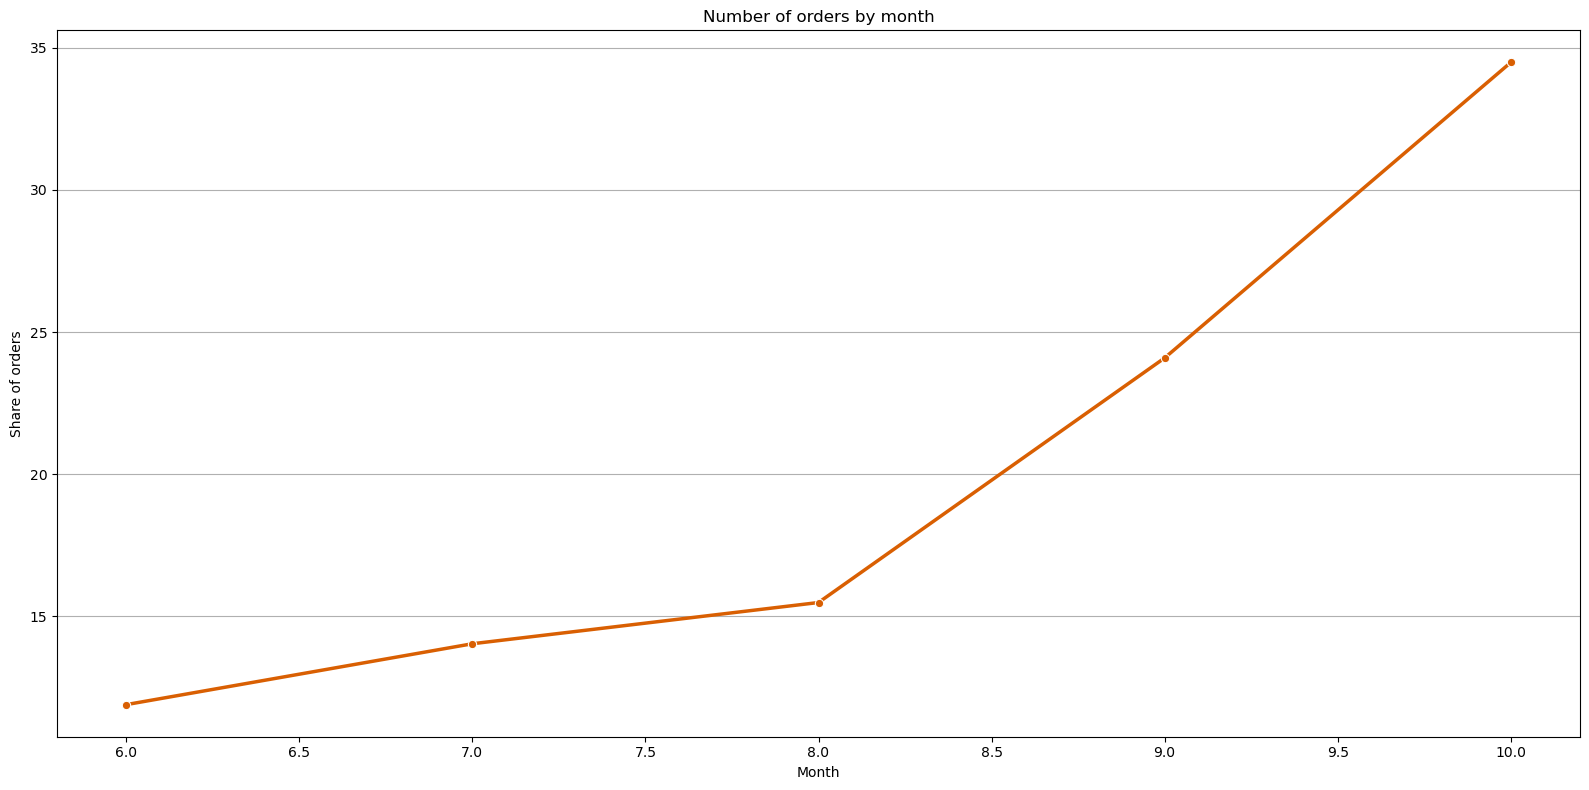

In [138]:
# Let's see the number of orders by month.
counts_per_month = orders_df.groupby('month').agg(
    orders_count=('order_id', 'count')).reset_index().sort_values(by='orders_count', ascending=False)

counts_per_month['orders_share'] = (100.0 * (counts_per_month['orders_count'] / counts_per_month['orders_count'].sum())).round(2)

display(counts_per_month)

plt.figure(figsize=(16, 8))
# let's make a schedule
sns.lineplot(data=counts_per_month,
            x='month',
            y='orders_share',
            color='#d95f02',
            marker='o',
            linewidth=2.5)


plt.ylabel('Share of orders')
plt.xlabel('Month')
plt.title('Number of orders by month')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The number of orders has been growing rapidly from June (34,235 orders or 11.90% share) to October (99,170 orders or 34.48% share), indicating a seasonal increase in user activity. The largest increase in values was observed between September (69,275 orders, 24.09% share) and October (99,170 orders, 34.48% share), an increase of 10% in share. 

In [143]:
# we only take data for the fall
autumn_data = orders_df[orders_df['season']=="autumn"].copy()

In [145]:
autumn_stats = pd.pivot_table(autumn_data,
    index='created_dt_msk',
    aggfunc={
        'order_id': 'count',
        'user_id': 'nunique',
        'one_ticket_revenue_rub': 'mean'
    }
).rename(columns={
    'order_id': 'total_orders',
    'user_id': 'dau',
    'one_ticket_revenue_rub': 'avg_ticket_price'
}).reset_index()
autumn_stats['orders_per_user'] = autumn_stats['total_orders'] / autumn_stats['dau'] 

display(autumn_stats)

,created_dt_msk,avg_ticket_price,total_orders,dau,orders_per_user
0,2024-09-01,223.580603,1327,564,2.352837
1,2024-09-02,225.388481,1376,573,2.401396
2,2024-09-03,125.584136,5094,777,6.555985
3,2024-09-04,230.072019,1761,684,2.574561
4,2024-09-05,229.284135,1941,738,2.630081
...,...,...,...,...,...
56,2024-10-27,224.621104,2844,1032,2.755814
57,2024-10-28,217.550909,2837,985,2.880203
58,2024-10-29,220.423433,2832,998,2.837675
59,2024-10-30,220.286535,2926,1040,2.813462


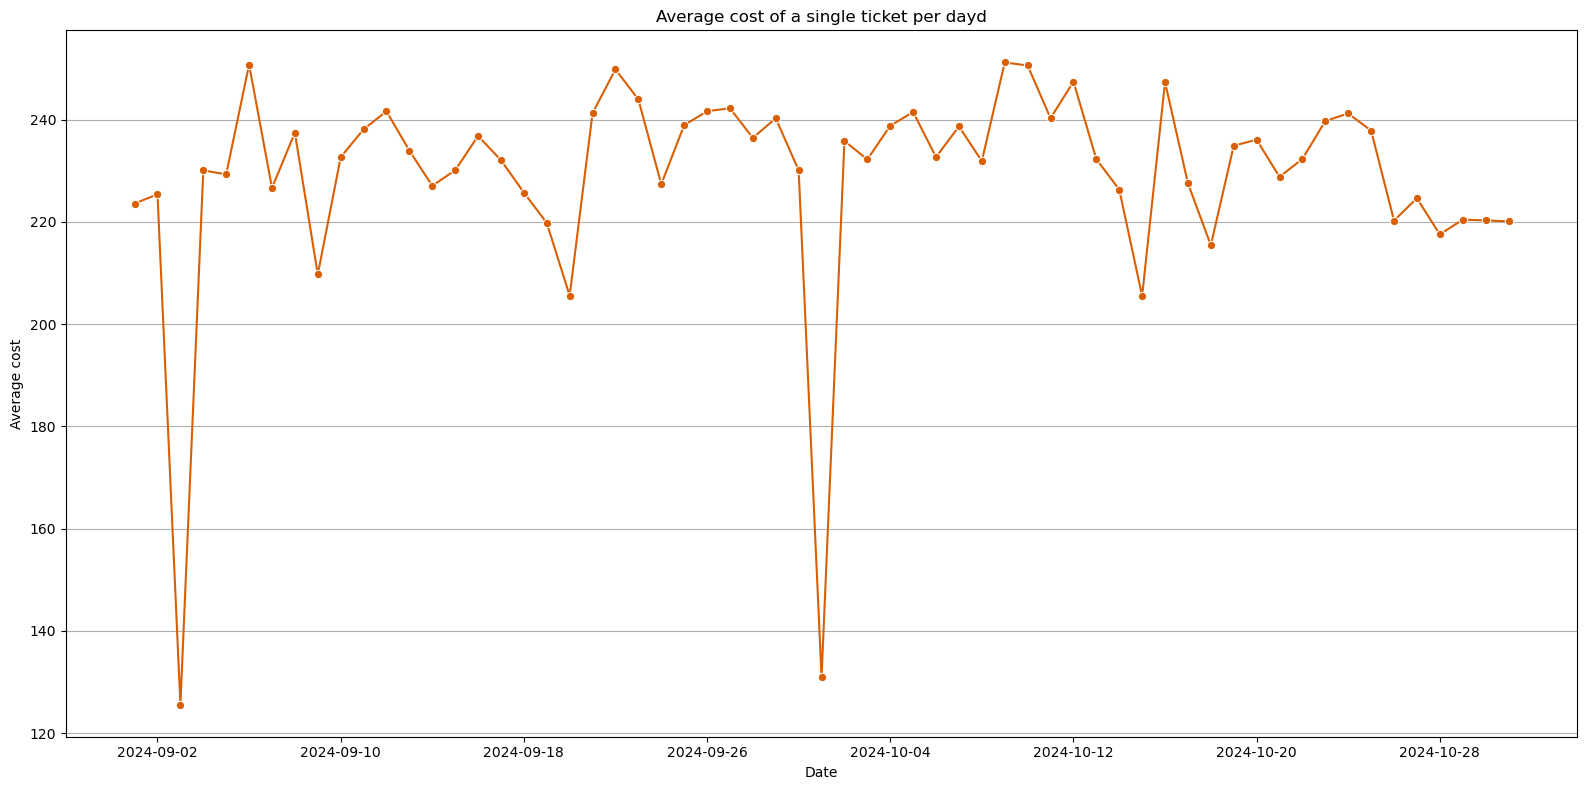

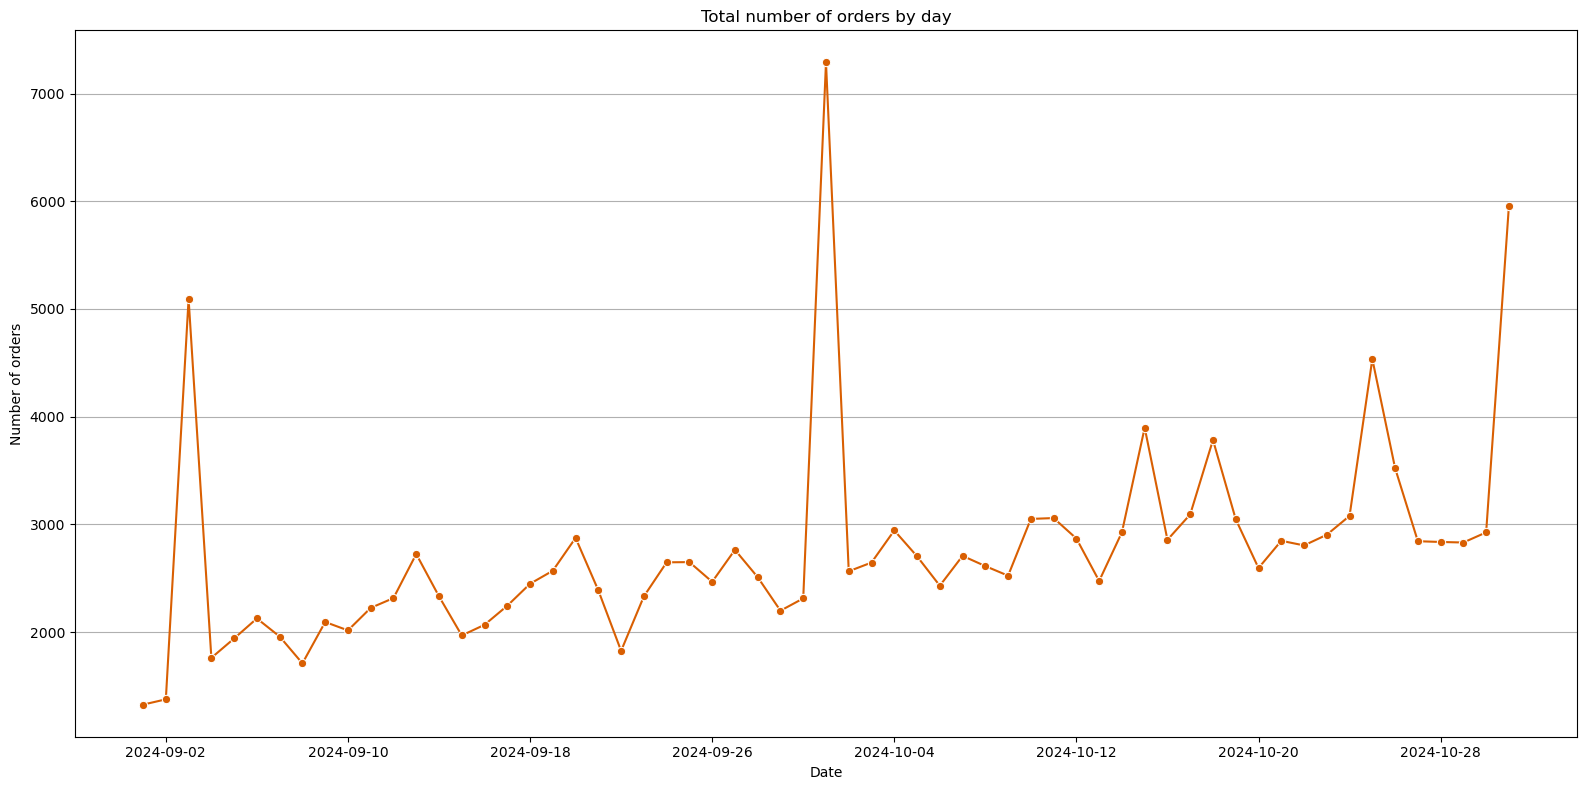

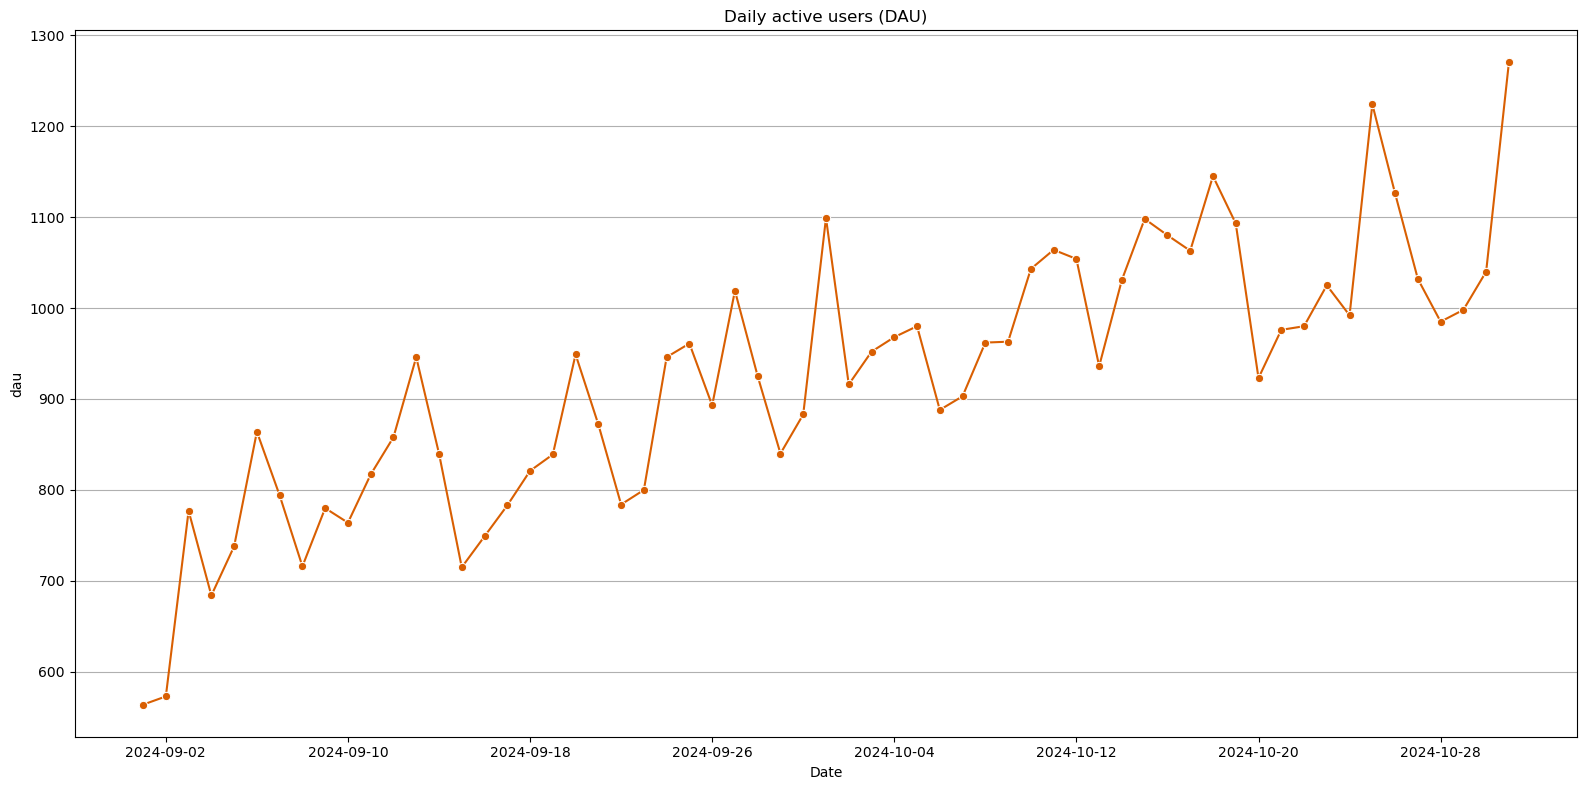

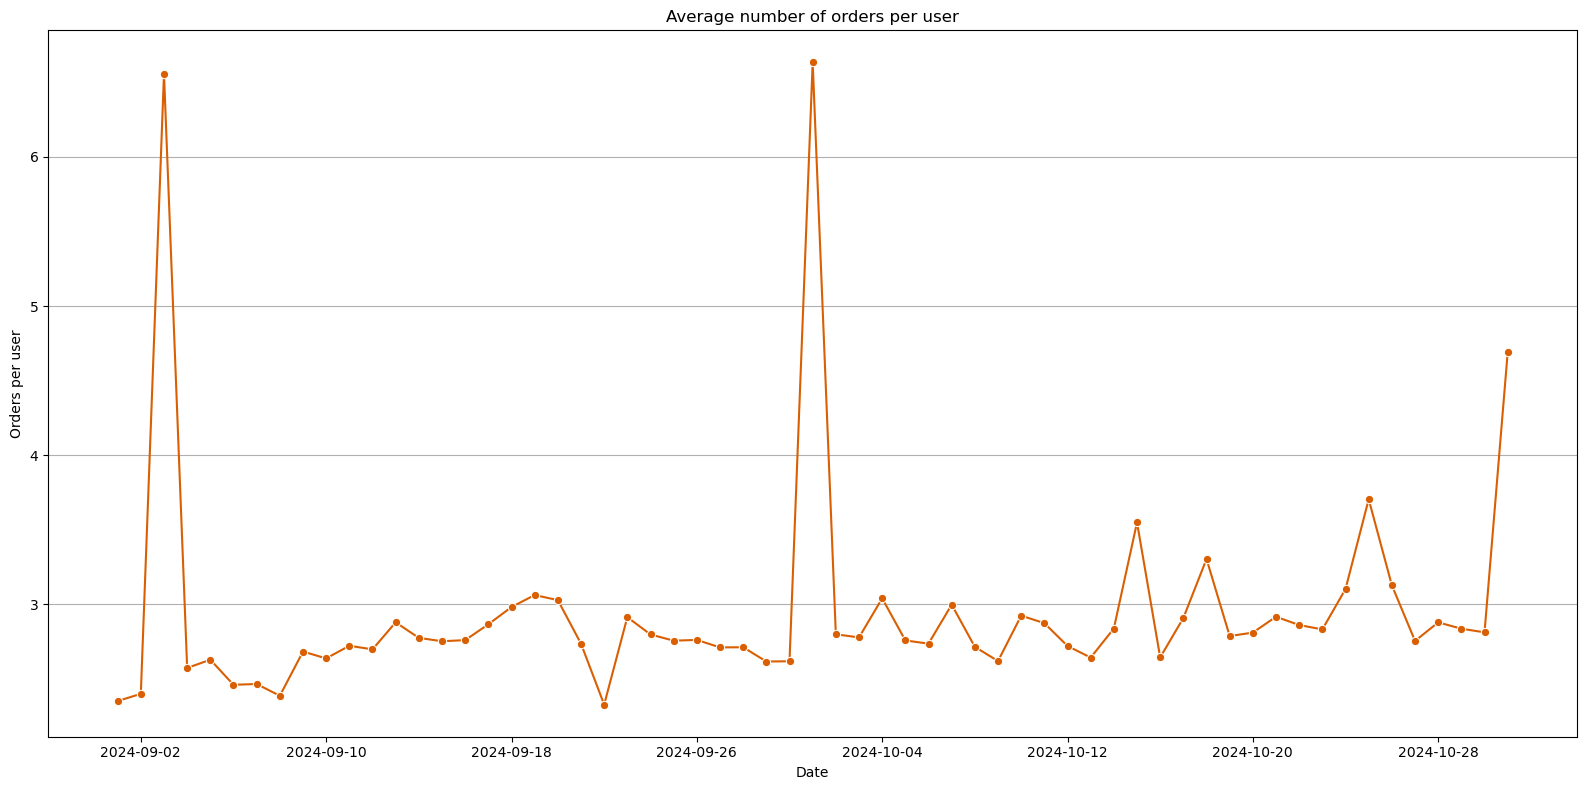

In [147]:
plt.figure(figsize=(16, 8))

# let's make a schedule
# average cost of a single ticket
ax_1 = sns.lineplot(data=autumn_stats,
            x='created_dt_msk',
            y='avg_ticket_price',
            color='#d95f02',
            marker='o',
            linewidth=1.5)

plt.ylabel('Average cost')
plt.xlabel('Date')
plt.title('Average cost of a single ticket per dayd')
plt.grid(axis='y')
plt.tight_layout()
ax_1.xaxis.set_major_locator(plt.MaxNLocator(10))

plt.show()

plt.figure(figsize=(16, 8))
# let's make a schedule
# total number of orders
ax_2 = sns.lineplot(data=autumn_stats,
            x='created_dt_msk',
            y='total_orders',
            color='#d95f02',
            marker='o',
            linewidth=1.5)

plt.ylabel('Number of orders')
plt.xlabel('Date')
plt.title('Total number of orders by day')
plt.grid(axis='y')
plt.tight_layout()
ax_2.xaxis.set_major_locator(plt.MaxNLocator(10))

plt.show()

plt.figure(figsize=(16, 8))
# let's make a schedule
# daily active users (DAU)
ax_3 = sns.lineplot(data=autumn_stats,
            x='created_dt_msk',
            y='dau',
            color='#d95f02',
            marker='o',
            linewidth=1.5)

plt.xlabel('Date')
plt.title('Daily active users (DAU)')
plt.grid(axis='y')
plt.tight_layout()
ax_3.xaxis.set_major_locator(plt.MaxNLocator(10))

plt.show()

plt.figure(figsize=(16, 8))
# let's make a schedule
# orders per user
ax_4 = sns.lineplot(data=autumn_stats,
            x='created_dt_msk',
            y='orders_per_user',
            color='#d95f02',
            marker='o',
            linewidth=1.5)

plt.ylabel('Orders per user')
plt.xlabel('Date')
plt.title('Average number of orders per user')
plt.grid(axis='y')
plt.tight_layout()
ax_4.xaxis.set_major_locator(plt.MaxNLocator(10))

plt.show()

In [149]:
# Let's create a column with the names of the days of the week.
autumn_stats['day_of_week'] = autumn_stats['created_dt_msk'].dt.day_name()

week_day = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


week_stats = autumn_stats.groupby('day_of_week').agg({
    'total_orders': 'mean'
}).reindex(week_day).reset_index()

display(week_stats)

,day_of_week,total_orders
0,Monday,2389.222222
1,Tuesday,3493.333333
2,Wednesday,2540.111111
3,Thursday,3013.333333
4,Friday,3101.625000
5,Saturday,2666.500000
6,Sunday,2152.888889


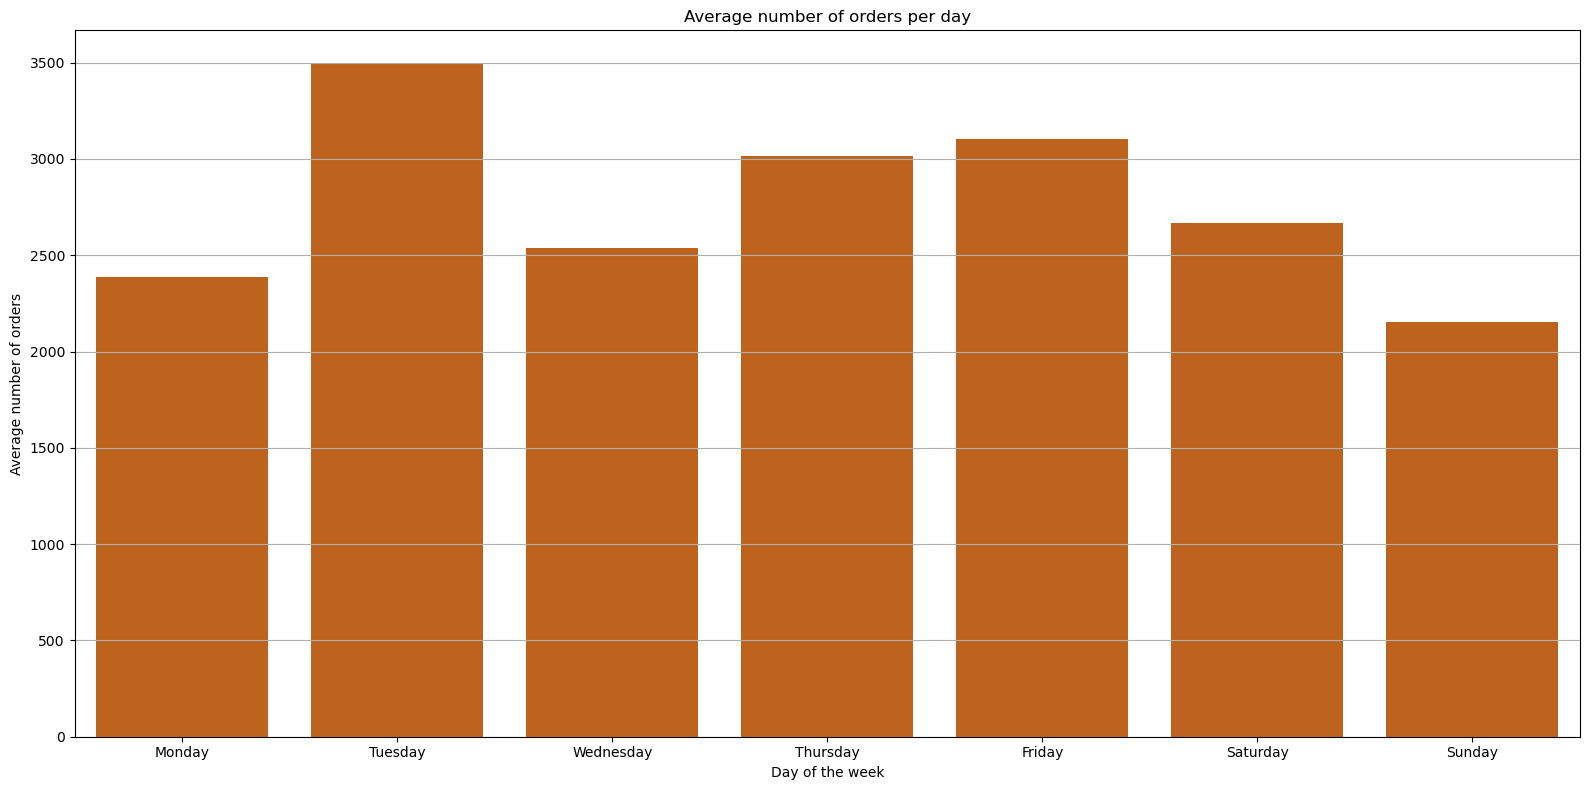

In [151]:
plt.figure(figsize=(16, 8))
# let's make a schedule
# orders per user
sns.barplot(data=week_stats,
            x='day_of_week',
            y='total_orders',
            color='#d95f02')

plt.ylabel('Average number of orders')
plt.xlabel('Day of the week')
plt.title('Average number of orders per day')
plt.grid(axis='y')
plt.tight_layout()

An analysis of weekly cycles in the fall showed clear patterns of activity. The highest number of orders was on Tuesday (3,493) and Friday (3,101). At the same time, Sunday (2,152) and Monday (2,389) showed a significant decline in values. Saturday (2,666) was not a very active day compared to weekdays. 

In [154]:
autumn_data_with_events = pd.merge(autumn_data, events_df, how='left', on='event_id')

regions_stats = autumn_data_with_events.groupby('region_name').agg(
    unique_events = ('event_id', 'nunique'),
    total_orders = ('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).reset_index().sort_values('unique_events', ascending=False)

# We will find the share of unique events in the region and immediately express it as a percentage.
regions_stats['event_share'] = (100.0 * (regions_stats['unique_events'] / regions_stats['unique_events'].sum())).round(2)
regions_stats['order_share'] = (100.0 * (regions_stats['total_orders'] / regions_stats['total_orders'].sum())).round(2)
regions_stats['revenue_share'] = (100.0 * (regions_stats['total_revenue'] / regions_stats['total_revenue'].sum())).round(2)

In [156]:
# Top 10 regions by diversity
top_regions = regions_stats.head(10)
print("Top 10 regions in terms of diversity of events")
display(top_regions)

Top 10 regions in terms of diversity of events


,region_name,unique_events,total_orders,total_revenue,event_share,order_share,revenue_share
23,Каменевский регион,3910,46684,24733557.14,24.68,27.72,29.33
59,Североярская область,2611,20704,10764125.56,16.48,12.29,12.76
75,Широковская область,796,8648,4425895.77,5.03,5.13,5.25
56,Светополянский округ,762,4771,2475944.44,4.81,2.83,2.94
51,Речиновская область,529,3565,1832814.33,3.34,2.12,2.17
60,Серебринская область,456,4467,2184074.62,2.88,2.65,2.59
76,Яблоневская область,431,4196,2070535.45,2.72,2.49,2.45
67,Тепляковская область,419,2485,1189547.76,2.65,1.48,1.41
11,Горицветская область,406,3230,1588283.95,2.56,1.92,1.88
63,Солнечноземская область,402,4197,1810346.35,2.54,2.49,2.15


In [158]:
services_stats = autumn_data_with_events.groupby('service_name').agg(
    unique_events = ('event_id', 'nunique'),
    total_orders = ('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).reset_index().sort_values('unique_events', ascending=False)

# find the share of unique events in the region
services_stats['event_share'] = (100.0 * (services_stats['unique_events'] / services_stats['unique_events'].sum())).round(2)
services_stats['order_share'] = (100.0 * (services_stats['total_orders'] / services_stats['total_orders'].sum())).round(2)
services_stats['revenue_share'] = (100.0 * (services_stats['total_revenue'] / services_stats['total_revenue'].sum())).round(2)

In [160]:
# Top 10 regions in terms of diversity
top_services = services_stats.head(10)
print("Top 10 operators by diversity of events")
display(top_services)

Top 10 operators by diversity of events


,service_name,unique_events,total_orders,total_revenue,event_share,order_share,revenue_share
21,Лови билет!,3611,25772,12857251.15,20.91,15.30,15.24
3,Билеты без проблем,2836,32328,16027263.67,16.43,19.19,19.00
5,Билеты в руки,2459,25652,10313065.87,14.24,15.23,12.23
25,Облачко,1409,15478,8508604.26,8.16,9.19,10.09
22,Лучшие билеты,1390,12419,5795516.43,8.05,7.37,6.87
24,Мой билет,1006,19419,10080044.99,5.83,11.53,11.95
30,Тебе билет!,858,3759,2004969.67,4.97,2.23,2.38
26,Прачечная,728,5798,2835456.84,4.22,3.44,3.36
8,Весь в билетах,599,9416,5465117.63,3.47,5.59,6.48
34,Яблоко,537,3473,1948510.53,3.11,2.06,2.31


The greatest variety of events is observed in the Kamenevsky region—3,910 unique events, which is 24.68% of the total number of orders. The Severo-Yarsky and Shirokovsky regions rank second and third in terms of the number of unique events and share of orders—16% and 5%, respectively.

The operator "Lovite Ticket!" leads in terms of variety of events, with 3,611 unique events (a share of 20.91%). It is followed by the operators Tickets Without Problems (2,836 events, 16.4% share) and Tickets in Hand (2,459 events, 14.24% share). Despite the difference in orders and revenue between the second place (Tickets Without Problems), it is Loviticket! that offers the greatest variety.

---
### 4. Statistical analysis of data

In [169]:
# We divide users by device type.
mobile_users = autumn_data[autumn_data['device_type_canonical']=='mobile'].copy()
desktop_users = autumn_data[autumn_data['device_type_canonical']=='desktop'].copy()

Let's start our test with the first hypothesis: the average number of orders per mobile app user is higher than that of desktop users.

The null and alternative hypotheses will look like this:
- Null hypothesis H₀: The average number of orders per mobile device user is no higher than that of desktop users
- Alternative hypothesis H₁: The average number of orders per user with a mobile device is higher than that of users of stationary devices.

For the test, we will use the Mann-Whitney statistical test, as it is less sensitive to outliers, and we have large outliers in the values:

In [172]:
# data for the first hypothesis 
orders_mobile = mobile_users.groupby('user_id')['order_id'].count()
orders_desktop = desktop_users.groupby('user_id')['order_id'].count()


# level of significance
alpha = 0.05

# we use the Mann-Whitney test
stat_mw, p_value_mw = mannwhitneyu(
    orders_mobile, orders_desktop,
    alternative='greater'
)

print(f"Mann–Whitney test results:")
# Let's calculate the resulting p-value
print(f"p-value: {p_value_mw:.3f}")
if p_value_mw > alpha:
    print('There is no difference: mobile users do not place more orders (H₀ is not rejected).')
else:
    print('Mobile users place more orders (H₀ is rejected).')

Mann–Whitney test results:
p-value: 0.000
Mobile users place more orders (H₀ is rejected).


The test results showed a p-value of 0.000, which means that the null hypothesis is rejected. The average number of orders placed by mobile users is statistically significantly higher than that of users of stationary devices.

Now let's test another hypothesis: the average time between orders for mobile app users is higher than for desktop users.
The null and alternative hypotheses will look like this:

- Null hypothesis H₀: The average time between orders for mobile device users is no greater than that for stationary device users.
- Alternative hypothesis H₁: The average time between orders for mobile device users is greater than that for stationary device users.

We will also use the Mann-Whitney statistical test for the test:

In [176]:
# data for the first hypothesis 
time_mobile = mobile_users.groupby('user_id')['days_since_prev'].mean().dropna()
time_desktop = desktop_users.groupby('user_id')['days_since_prev'].mean().dropna()

# level of significance
alpha = 0.05

# we use the Mann-Whitney test
stat_mw_2, p_value_mw_2 = mannwhitneyu(
    time_mobile, time_desktop,
    alternative='greater'
)

print(f"Mann–Whitney test results:")
# Let's calculate the resulting p-value
print(f"p-value: {p_value_mw_2:.3f}")
if p_value_mw_2 > alpha:
    print('There is no difference: mobile users do not place orders at long intervals (H₀ is not rejected).')
else:
    print('Mobile users place orders at longer intervals (H₀ is rejected).')

Mann–Whitney test results:
p-value: 0.000
Mobile users place orders at longer intervals (H₀ is rejected).


The results of the second Mann–Whitney test (p-value = 0.000) showed that the null hypothesis is rejected. Mobile users place orders at longer intervals than users of stationary devices.

---

### 5. Overall conclusion and recommendations

In this project, the `final_tickets_orders_df` and `final_tickets_orders_df` datasets were loaded, which contained a total of 25 columns with 290,849 rows, and the following actions were performed:

- Reviewed the data in both dataframes
- We preprocessed the data - corrected data types, examined missing data, and examined the data for explicit and implicit duplicates, and finally created new columns - `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`
- The most significant work was the `research data analysis`, where we examined various relationships in the data and tested two hypotheses

- Popularity of events: concerts were the most frequently attended, while theaters were less popular. In the summer, there was high demand for children's events (ages 6 to 12), while in the fall, events without age restrictions peaked.

- Seasonal activity: the number of orders grew steadily from 34,000 orders in June to almost 100,000 in November, with a particularly noticeable jump between September and October (+35%). Autumn has a higher peak in demand.

- Average check: average revenue per ticket was higher in the summer, especially in the concerts category. (270 rubles in summer vs. 250 rubles in autumn)

- Regional leaders: The Kamenevsky region is the leader in all indicators: number of events, orders, and revenue

- Operator leaders: Loviticket! and Tickets Without Problems are the main partners in terms of variety of offers and financial indicators

Both statistical tests showed differences between mobile and desktop users (in both tests, the p-value was 0.000). Mobile users place more orders, but with longer intervals between them.

This means continuing to develop the mobile interface to retain users and attract new audiences. It also means considering push notifications and marketing campaigns to reduce the time between orders.